In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionando a pasta raiz ao path para conseguir importar a pasta mlp
sys.path.append(os.path.abspath('..'))

from mlp.network import MLP, LinearLayer
from mlp.activations import ReLU, Softmax
from mlp.optimizers import train, train_with_history

In [ ]:
import os
import urllib.request
import numpy as np

# Define o caminho para salvar o arquivo de dados localmente
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, 'mnist.npz')

# Faz o download direto do arquivo bruto do MNIST se ele não existir localmente
if not os.path.exists(data_path):
    print("Baixando o dataset MNIST via URL direta...")
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    urllib.request.urlretrieve(url, data_path)
    print("Download concluído com sucesso!")

# Carrega as matrizes nativamente usando apenas o NumPy
with np.load(data_path) as data:
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']

# Pré-processamento manual idêntico ao original:
# 1. Flatten e Normalização (0 a 1)
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
x_test = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

# 2. One-hot encoding das labels
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

print(f"Dados carregados com sucesso utilizando 100% NumPy!")
print(f"Formato dos dados de Treino: {x_train.shape}, Teste: {x_test.shape}")

In [ ]:
def evaluate(model, x, y):
    preds = np.argmax(model.forward(x), axis=1)
    return np.mean(preds == y)

final_model = MLP()
final_model.add_layer(LinearLayer(784, 128, 0.1), ReLU())
final_model.add_layer(LinearLayer(128, 64, 0.1), ReLU())
final_model.add_layer(LinearLayer(64, 10, 0.1), Softmax())

losses = train_with_history(final_model, x_train, y_train_oh)

print(f"\nTeste Acc: {evaluate(final_model, x_test, y_test)*100:.2f}%")

In [ ]:
plt.plot(losses)
plt.title('Curva de Convergência (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')

# Salvando a figura na pasta de results como pedido
plt.savefig('../results/curva_de_loss.png')
plt.show()

## Adiciona Mais Experimentos

### Learning Rates

Iniciando o experimento de Taxas de Aprendizado...
-> Treinando com Learning Rate = 0.1
Epoch 1 Loss: 0.3421
Epoch 2 Loss: 0.1526
Epoch 3 Loss: 0.1115
Epoch 4 Loss: 0.0865
Epoch 5 Loss: 0.0710
-> Treinando com Learning Rate = 0.01
Epoch 1 Loss: 0.9050
Epoch 2 Loss: 0.3653
Epoch 3 Loss: 0.3046
Epoch 4 Loss: 0.2720
Epoch 5 Loss: 0.2476
-> Treinando com Learning Rate = 0.001
Epoch 1 Loss: 2.0491
Epoch 2 Loss: 1.4812
Epoch 3 Loss: 1.0403
Epoch 4 Loss: 0.7930
Epoch 5 Loss: 0.6559


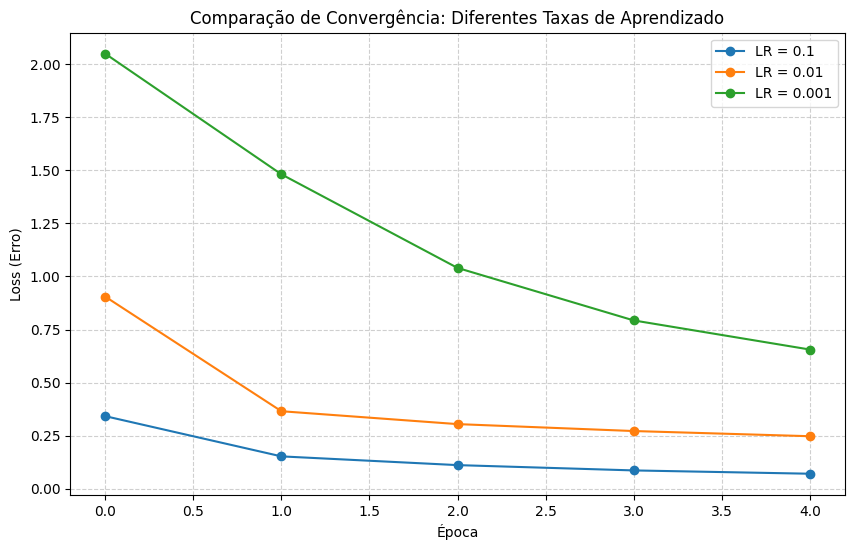

Gráfico 'comparacao_learning_rates.png' salvo com sucesso em results!


In [5]:
import matplotlib.pyplot as plt
from mlp.network import MLP, LinearLayer
from mlp.activations import ReLU, Softmax
from mlp.optimizers import train_with_history

# Taxas de aprendizado que vamos testar
learning_rates = [0.1, 0.01, 0.001]
resultados_lr = {}

print("Iniciando o experimento de Taxas de Aprendizado...")

for lr in learning_rates:
    print(f"-> Treinando com Learning Rate = {lr}")
    # Instancia uma nova rede para cada teste
    modelo_teste = MLP()
    modelo_teste.add_layer(LinearLayer(784, 128, learning_rate=lr), ReLU())
    modelo_teste.add_layer(LinearLayer(128, 64, learning_rate=lr), ReLU())
    modelo_teste.add_layer(LinearLayer(64, 10, learning_rate=lr), Softmax())
    
    # Treina por 5 épocas
    historico_loss = train_with_history(modelo_teste, x_train, y_train_oh, epochs=5, batch_size=64)
    resultados_lr[lr] = historico_loss

# Gerar e salvar o gráfico comparativo
plt.figure(figsize=(10, 6))
for lr, losses in resultados_lr.items():
    plt.plot(losses, marker='o', label=f'LR = {lr}')

plt.title('Comparação de Convergência: Diferentes Taxas de Aprendizado')
plt.xlabel('Época')
plt.ylabel('Loss (Erro)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Salvando na pasta results (subindo um nível com '../')
plt.savefig('../results/comparacao_learning_rates.png', bbox_inches='tight')
plt.show()
print("Gráfico 'comparacao_learning_rates.png' salvo com sucesso em results!")

### Matriz de Confusão

In [ ]:
# Obtém as previsões do modelo final para o conjunto de teste
previsoes_brutas = final_model.forward(x_test)
preds = np.argmax(previsoes_brutas, axis=1)

# Cria uma matriz 10x10 preenchida com zeros usando NumPy
matriz_confusao = np.zeros((10, 10), dtype=int)

# Preenche a matriz comparando o valor Real com o Predito
for real, predito in zip(y_test, preds):
    matriz_confusao[real, predito] += 1

# Plotar a matriz graficamente
plt.figure(figsize=(9, 9))
plt.imshow(matriz_confusao, cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste (MNIST)', fontsize=14)
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel('Dígito Predito pelo Modelo', fontsize=12)
plt.ylabel('Dígito Real (Gabarito)', fontsize=12)

# Escreve os números dentro dos quadrados da matriz
limiar = matriz_confusao.max() / 2.0
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(matriz_confusao[i, j]),
                 ha="center", va="center",
                 color="white" if matriz_confusao[i, j] > limiar else "black")

# Salvando na pasta results
plt.savefig('../results/matriz_confusao.png', bbox_inches='tight')
plt.show()
print("Gráfico 'matriz_confusao.png' salvo com sucesso em results!")